In [ ]:
pip install pandas

In [ ]:
# to import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()


Saving Customer_Churn.csv to Customer_Churn.csv


In [ ]:
df = pd.read_csv('Customer_Churn.csv')
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


in eda we do first , inspect our data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [ ]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
# i also to convert the datatype of this column as this columns consist numericalvsalues
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
#to create function to change data in seniorcitizencolumn
# senior citizen column has 0,1 values as 0-> no , 1-> yes

def conv(value):
  if value ==1:
    return "yes"
  else:
    return "no"

df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
now we have reached to the part where we can start mentioning analysis

In [ ]:
why customers are churned out?
why they are stop using our services?
characteristics of customers ki kis kis type ke customers hai

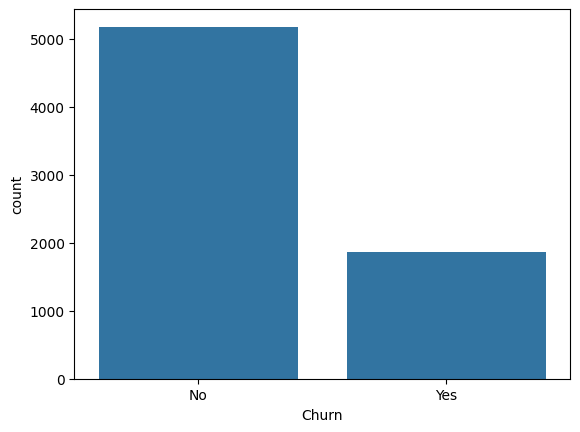

In [ ]:
#to check how many customers are chrun out or not
sns.countplot(x= df["Churn"])
plt.show()

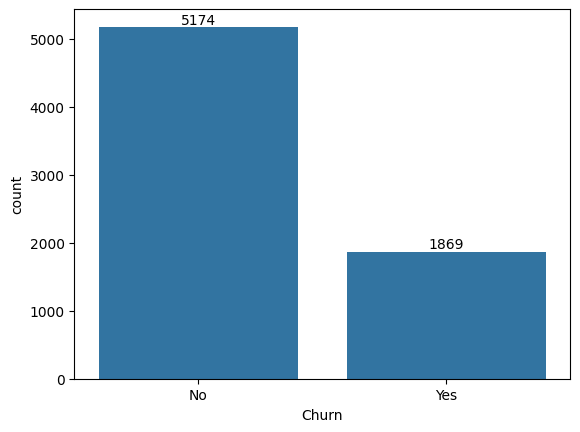

In [ ]:
ax= sns.countplot(x= df["Churn"])
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
#to check this values in percentage WE CAN USE PIECHART

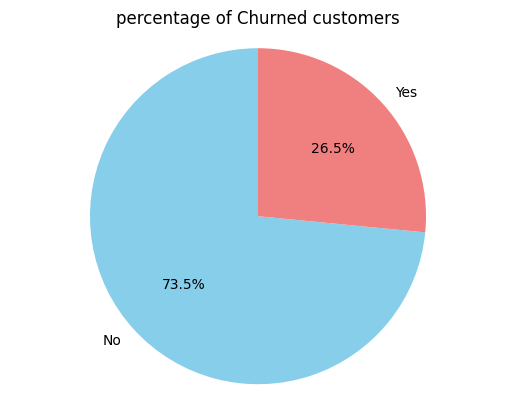

In [ ]:
churn_counts = df['Churn'].value_counts()

plt.pie(churn_counts,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue', 'lightcoral'])


plt.title('percentage of Churned customers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

from the given pie chart we can conclude that 26.5% of our customers have chruned out.
no

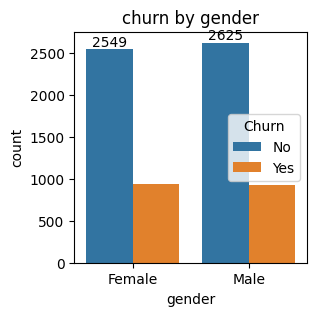

In [51]:
plt.figure(figsize =(3,3))
ax= sns.countplot(x= "gender", hue="Churn", data=df)
ax.bar_label(ax.containers[0])

plt.title("churn by gender")
plt.show()

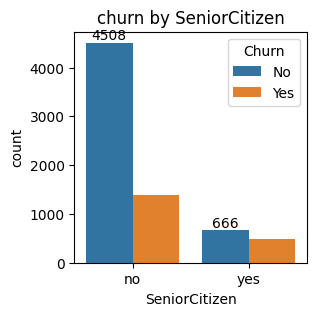

In [55]:
plt.figure(figsize =(3,3))
ax= sns.countplot(x= "SeniorCitizen", hue="Churn", data=df)
ax.bar_label(ax.containers[0])

plt.title("churn by SeniorCitizen")
plt.show()

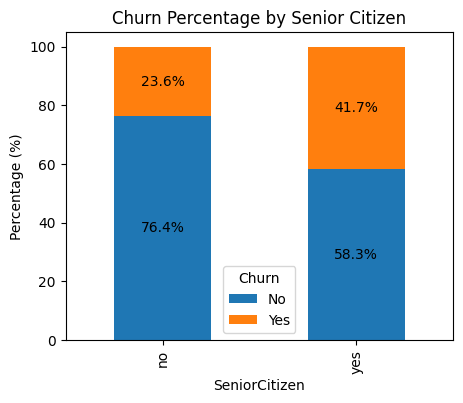

In [56]:
churn_pct = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).mul(100).unstack()
ax = churn_pct.plot(kind='bar', stacked=True, figsize=(5,4))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title('Churn Percentage by Senior Citizen')
plt.ylabel('Percentage (%)')
plt.show()

comparative a greater percentage of people in senior citizen category have churned

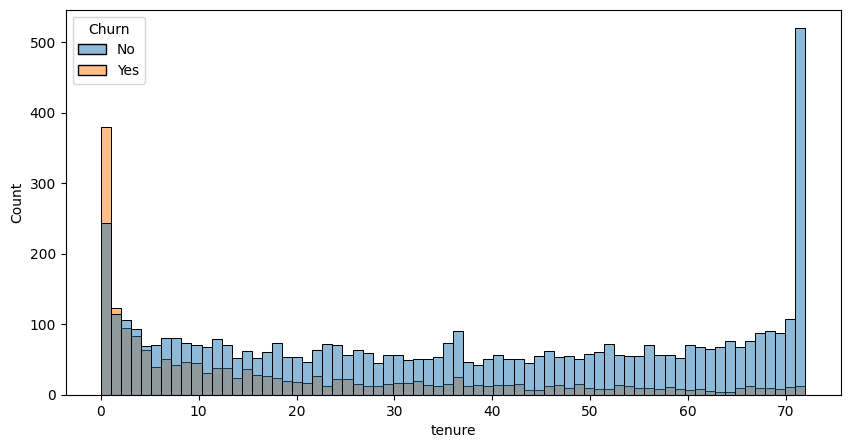

In [65]:
plt.figure(figsize =(10,5))
sns.histplot(x="tenure", data =df, bins=70,hue="Churn")
plt.show()

people who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned

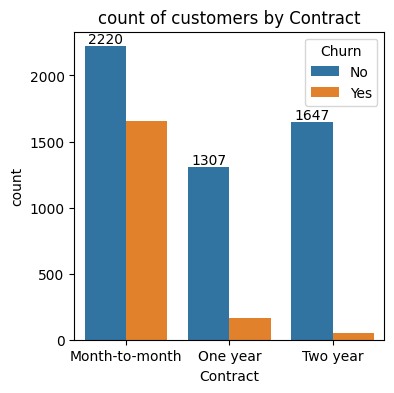

In [69]:
plt.figure(figsize =(4,4))
ax= sns.countplot(x= "Contract", data=df,hue="Churn")
ax.bar_label(ax.containers[0])

plt.title("count of customers by Contract")
plt.show()

people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [70]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

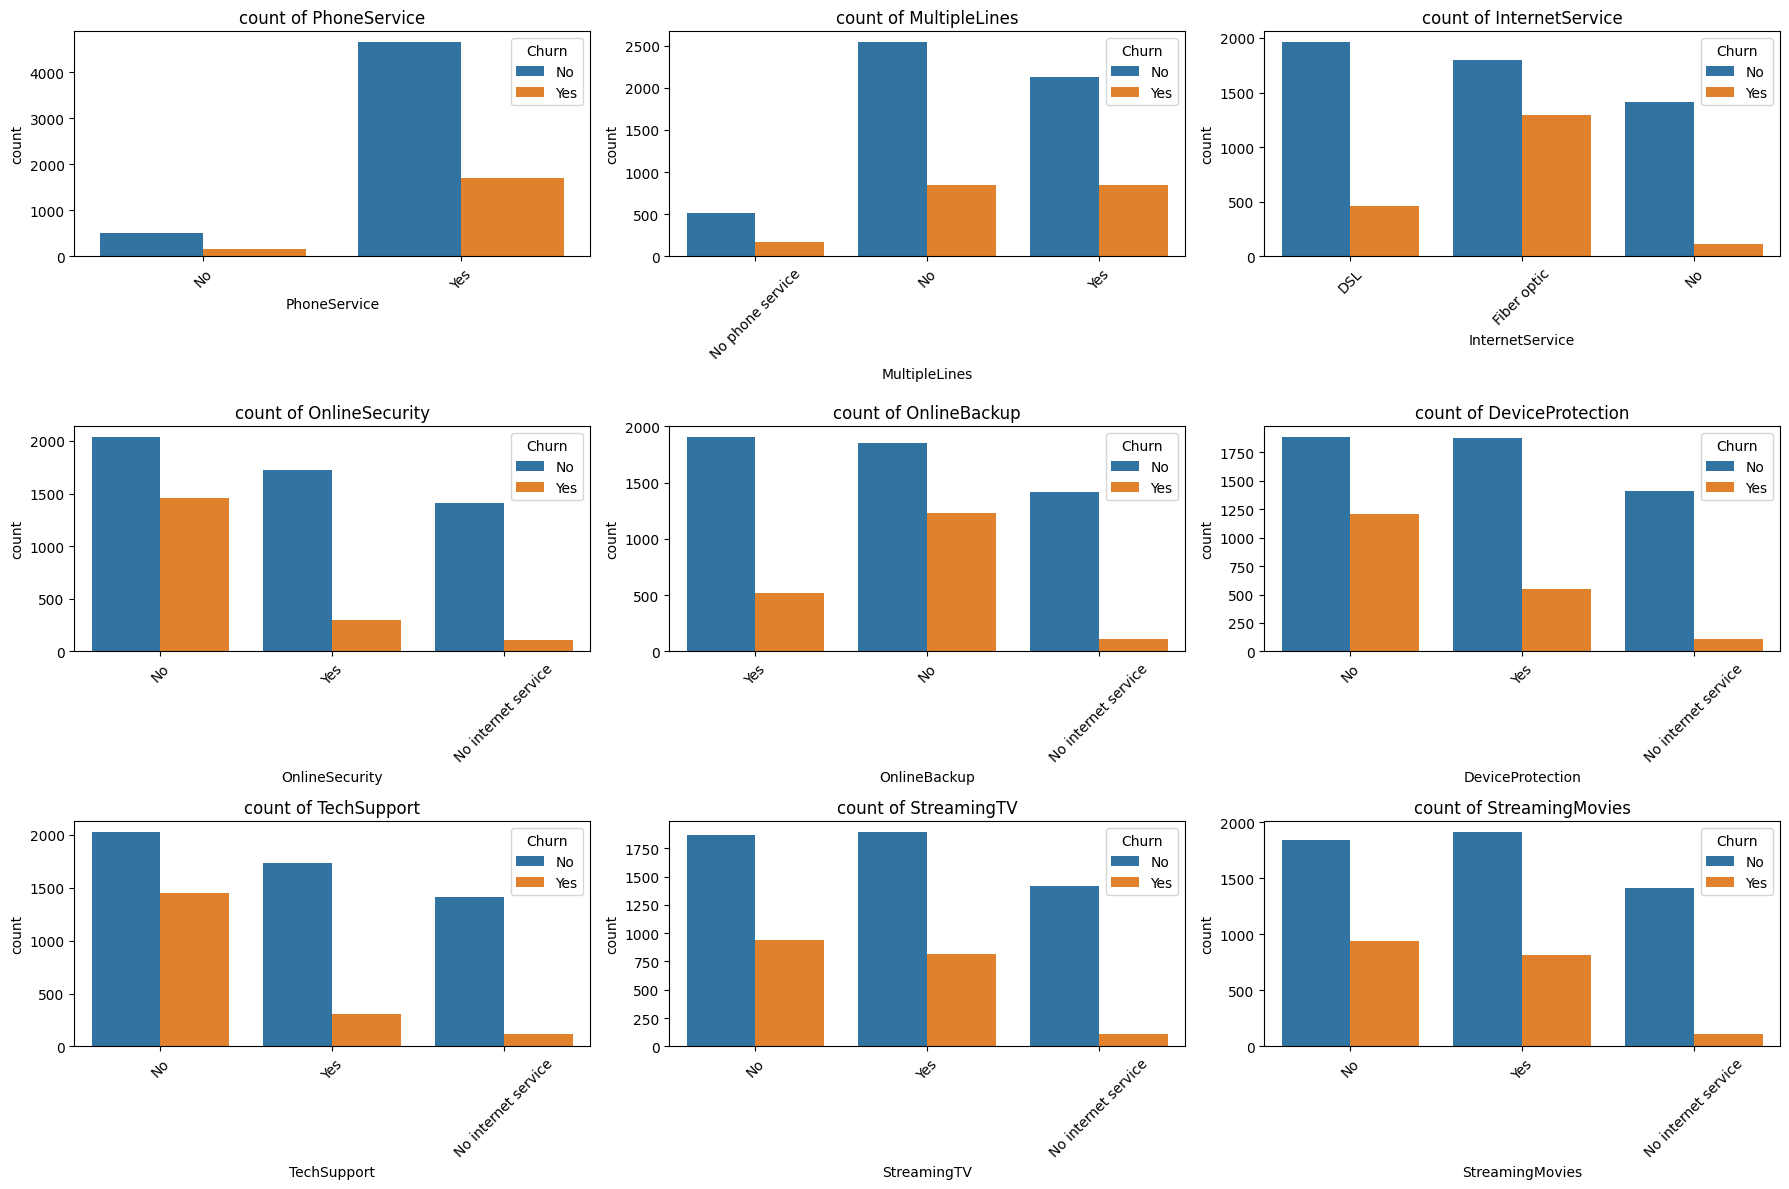

In [78]:
cols = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f"count of {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Customers using **Fiber Optic internet** are leaving the company more often than customers using DSL internet.
# Customers who **do not have Online Security, Tech Support, Backup, or Device Protection** are more likely to leave.
# Customers who use **Online Security, Tech Support, Backup, and Protection services** tend to stay with the company longer.
# **Streaming TV and Streaming Movies** do not seem to have a big effect on whether customers stay or leave.


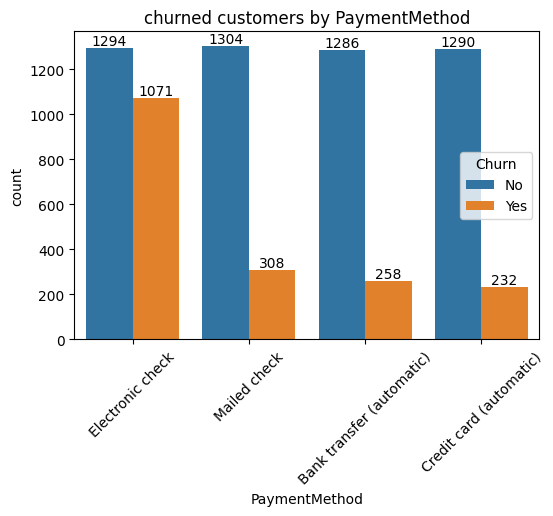

In [84]:
plt.figure(figsize =(6,4))
ax= sns.countplot(x= "PaymentMethod", data=df,hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("churned customers by PaymentMethod")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Customers who pay using Electronic Check have the highest number of churns (customers leaving the company).
# Customers using Automatic Bank Transfer or Automatic Credit Card payments are much less likely to leave.
# Mailed Check users have a moderate churn rate, higher than automatic payment users but lower than electronic check users.
# Overall, customers enrolled in automatic payment methods tend to stay longer, while those using electronic checks are more likely to churn.